## INTRO TO CNNs - Convolutional Neural Networks

## INTRO TO GenAI

## INTRO TO NLP

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf

In [39]:
import warnings

warnings.filterwarnings("ignore")


In [2]:
# get the data
data = tf.keras.datasets.mnist.load_data()
data

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


((array([[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         ...,
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0

In [3]:
type(data)

tuple

In [4]:
len(data)

2

In [6]:
len(data[0])

2

<function matplotlib.pyplot.show(close=None, block=None)>

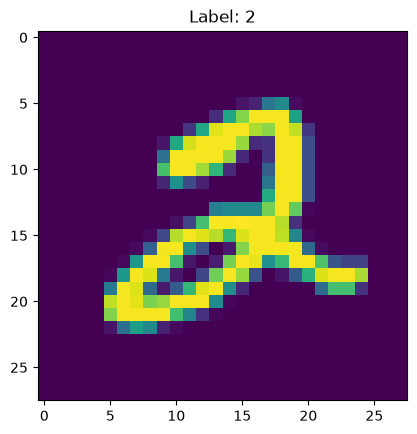

In [24]:
# data[0] # shape=(60000, 28, 28), dtype=uint8)

# data[1] # shape=(10000, 28, 28)

len(data[0][0]) # 60000 -- images  --> every one is 28 x 28
len(data[0][1]) # 60000 -- labels  --> you have a digit as well
# 60k images, 2D images

np.set_printoptions(linewidth = 150)   

# print(data[0][0][0]) # seroth image# 

plt.imshow(data[0][0][5])
plt.title(f"Label: {data[0][1][5]}")
plt.show


In [21]:
(X_train, y_train), (X_test, y_test) = data

<function matplotlib.pyplot.show(close=None, block=None)>

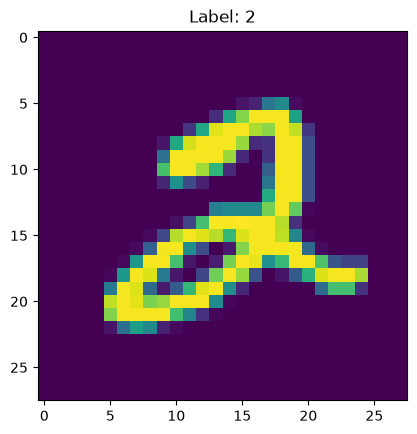

In [22]:
data[0] # -- training set
data[1] # -- testing set

len(data[0][0]) # -- X_train
len(data[0][1]) # -- y_train


plt.imshow(X_train[5])
plt.title(f"Label: {y_train[5]}")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

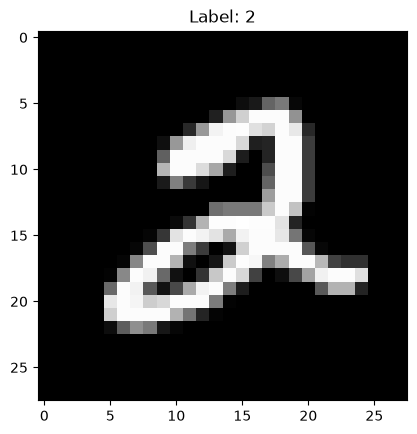

In [ ]:
data[0] # -- training set
data[1] # -- testing set

len(data[0][0]) # -- X_train
len(data[0][1]) # -- y_train


plt.imshow(X_train[5], cmap='gray') # colormap
plt.title(f"Label: {y_train[5]}")
plt.show

In [29]:
X_train[5].shape

(28, 28)

In [33]:
X_train[5].reshape(1, 28,28)

array([[[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  13,  25, 100, 122,   7,   0,   0,   0,   0,   0,   0,   0,
           0],
        [  0,   0,   0,   0,   0,   0,   0,   

In [ ]:
len

In [44]:
np.unique(y_train) # to know the total num of classes

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [40]:
# Modeling

from tensorflow.keras import layers

DL_model = tf.keras.models.Sequential([
    # input layer
    layers.Flatten(input_shape = (28,28)), # squishes from 2D to 1D array
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

DL_model.compile(optimizer='adam', loss = 'sparse_categorical_crossentropy', metrics=['accuracy'])

DL_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
# Train & Evaluate

DL_model.fit(X_train, y_train, epochs = 3, batch_size = 10)

test_loss, test_acc = DL_model.evaluate(X_test, y_test)

Epoch 1/3
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.8464 - loss: 1.7416
Epoch 2/3
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9038 - loss: 0.4020
Epoch 3/3
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9204 - loss: 0.3477
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9205 - loss: 0.3560


In [43]:
print(f"Test accuracy of the model is: {test_acc*100:.2f}%")

Test accuracy of the model is: 92.05%


In [48]:
DL_model.predict(X_test)
X_test.shape

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 963us/step


(10000, 28, 28)

In [51]:
img = X_test[10]

img.reshape(1,28,28).shape # (1, 28, 28)

np.expand_dims(img, 0).shape

(1, 28, 28)

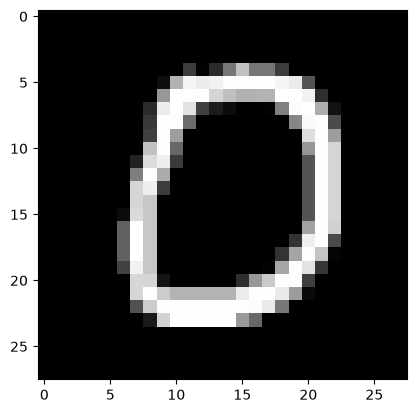

In [46]:
# make an arbirrary prediction

img = X_test[10]

plt.imshow(img, cmap='gray')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


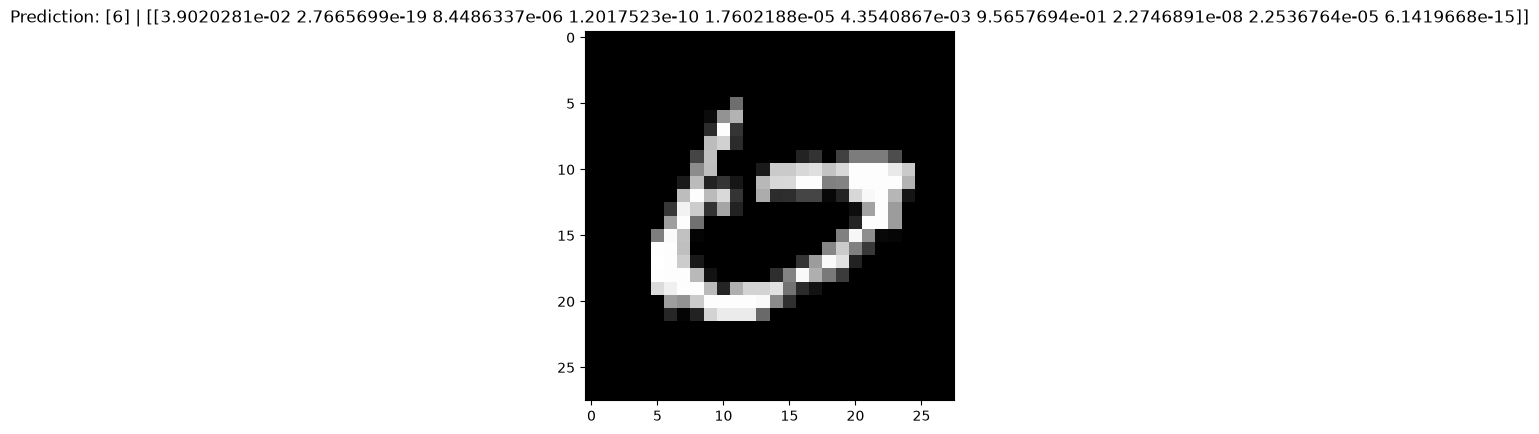

In [58]:
# make an arbirrary prediction

img = X_test[445]

prediction_img = DL_model.predict(img.reshape(1,28,28))

prediction_label = np.argmax(prediction_img, axis = 1)
confidence = prediction_img[0][prediction_label]

# prediction_img.round(2)

plt.imshow(img, cmap='gray')
plt.title(f"Prediction: {prediction_label} | {prediction_img}")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


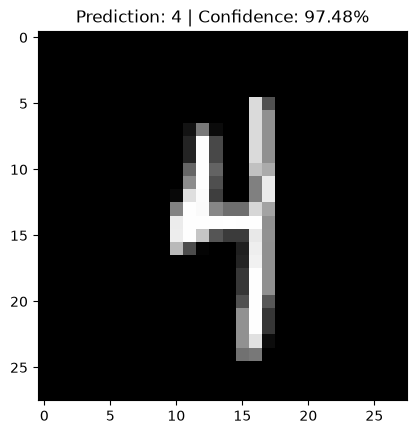

In [64]:
# make an arbitrary prediction
 
img = X_test[65]

prediction_img = DL_model.predict(img.reshape(1, 28, 28))

prediction_label = np.argmax(prediction_img, axis=1)[0]
confidence = prediction_img[0][prediction_label]

plt.imshow(img, cmap='gray')
plt.title(f"Prediction: {prediction_label} | Confidence: {confidence*100:.2f}%")
plt.show()
 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


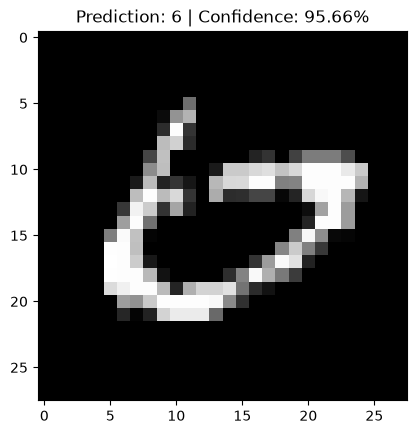

In [61]:
img = X_test[445]

prediction_img = DL_model.predict(img.reshape(1, 28, 28))

prediction_label = np.argmax(prediction_img)
confidence = prediction_img[0][prediction_label].item()

plt.imshow(img, cmap='gray')
plt.title(f"Prediction: {prediction_label} | Confidence: {confidence*100:.2f}%")
plt.show()

In [71]:
predictions = DL_model.predict(X_test)

y_pred = np.argmax(predictions, axis=1)

report = classification_report(y_pred, y_test)

print(report)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 895us/step
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       954
           1       0.97      0.99      0.98      1121
           2       0.88      0.97      0.92       943
           3       0.91      0.93      0.92       991
           4       0.94      0.93      0.93       992
           5       0.87      0.90      0.88       864
           6       0.84      0.97      0.90       833
           7       0.93      0.97      0.95       987
           8       0.96      0.74      0.83      1266
           9       0.93      0.89      0.91      1049

    accuracy                           0.92     10000
   macro avg       0.92      0.93      0.92     10000
weighted avg       0.92      0.92      0.92     10000



In [88]:
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dropout, Dense
from tensorflow.keras.models import Sequential

def nomie_cnn(input_shape = (28,28,1), num_classes = 10):
    model = Sequential()

    # part 1: edge & basic shape detection
    model.add(Conv2D(filters = 32, input_shape = input_shape, kernel_size = (3,3), activation = 'relu'))
    model.add(MaxPool2D(pool_size = (2,2)))

    # part 2 : detect more features
    model.add(Conv2D(filters = 64, kernel_size = (3,3), activation = 'relu'))
    model.add(MaxPool2D(pool_size = (2,2)))

    # conversion to 1D
    model.add(Flatten())

    #we add droputs, to reduce overfitting
    model.add(Dropout(0.5)) # turn off 50% of the neuron

    # add a dense layer --> fully connected
    model.add(Dense(128, activation = 'relu'))

    # output layer
    model.add(Dense(units = num_classes, activation = 'softmax'))

    
    model.compile(optimizer='adam', loss = 'sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


In [89]:
model = nomie_cnn()
model.summary()


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [90]:
# data
data = tf.keras.datasets.mnist.load_data()

(X_train, y_train), (X_test, y_test) = data

X_train.shape

(60000, 28, 28)

In [ ]:
# data processing

# usually tensorflow usually take 3D shape, hence we change from 2D to 3D
X_train = X_train.reshape(60000,28,28,1)
X_test = X_test.reshape(10000,28,28,1)

# we perform scaling operations as well to improve model performance
# if there's any big values in data -- gradient descent faces issue - explosive gradient
X_train = X_train/225
X_test = X_test/225


In [98]:
history = model.fit(X_train, y_train,
          epochs = 5,
          batch_size = 10,
          validation_split = 0.2)

# history can be used to plot the test vs training accuracies over the multiple epochs

Epoch 1/5
4800/4800 ━━━━━━━━━━━━━━━━━━━━ 52s 11ms/step - accuracy: 0.9890 - loss: 0.0336 - val_accuracy: 0.9923 - val_loss: 0.0302
Epoch 2/5
4800/4800 ━━━━━━━━━━━━━━━━━━━━ 88s 18ms/step - accuracy: 0.9894 - loss: 0.0333 - val_accuracy: 0.9925 - val_loss: 0.0279
Epoch 3/5
4800/4800 ━━━━━━━━━━━━━━━━━━━━ 100s 21ms/step - accuracy: 0.9908 - loss: 0.0287 - val_accuracy: 0.9933 - val_loss: 0.0288
Epoch 4/5
4800/4800 ━━━━━━━━━━━━━━━━━━━━ 60s 13ms/step - accuracy: 0.9912 - loss: 0.0263 - val_accuracy: 0.9918 - val_loss: 0.0388
Epoch 5/5
4800/4800 ━━━━━━━━━━━━━━━━━━━━ 45s 9ms/step - accuracy: 0.9916 - loss: 0.0258 - val_accuracy: 0.9926 - val_loss: 0.0342


In [99]:
# evaluation

test_loss, test_accuracy = model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9931 - loss: 0.0255


In [100]:
# save the  model for tensorflow : .keras, .h5, SaveModel format

model.summary()

model.save('nomie_digit_recog_model.keras')



Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,104 (2.58 MB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 450,070 (1.72 MB)

In [95]:
arr = np.array([[1, 2, 3, 4],
                [1, 2, 3, 4],
                [1, 2, 3, 4]
                ])

arr.shape

(3, 4)

In [ ]:
## TEST with REAL INPUTS



In [101]:
import numpy as np

from PIL import Image, ImageOps

import tensorflow as tf

In [104]:
# load the model 

model = tf.keras.models.load_model('nomie_digit_recog_model.keras')

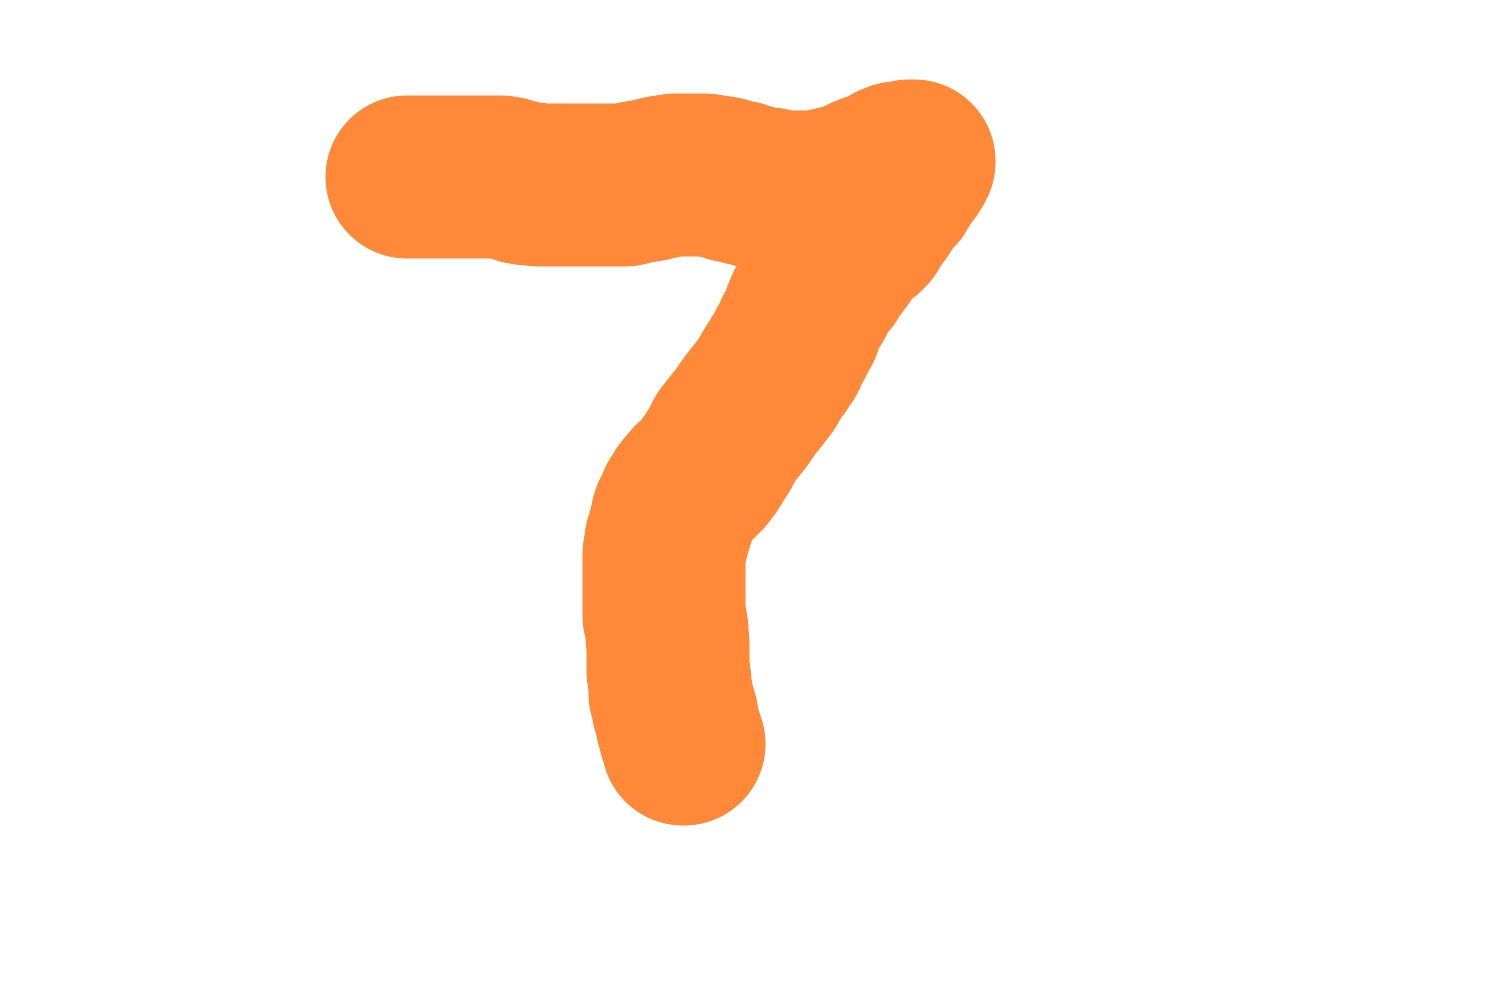

[[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  2 27 31 27 14 16 33 31  9 16 60 59  5  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 48 97 95 93 89 90 95 95 84 87 96 98 41  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  2 78 94 92 92 93 93 92 92 93 93 92 96 57  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  2 77 94 92 92 92 92 92 92 92 92 92 96 44  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 45 95 93 95 96 96 93 93 92 92 93 87 12  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  1 21 25 35 45 44 27 48 94 92 96 54  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0 48 96 93 85 11  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  5 81 93 96 52  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 41 96 92 93 22  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  4 79 94

(1, 28, 28, 1)

In [134]:
# take the image, and make predictions using the model

path = 'test_1.jpg'

img = Image.open(path)
display(img)

# data preprocessing
img.size
# size is (513, 398)
img = img.resize((28,28))
display(img)

# greyscale the image
img = img.convert('L') # change the 4 channel image into grey scale
display(img)

# will turn white into black
img = ImageOps.invert(img) # ivnerts the image

# convert into a numpy array
img_array = np.array(img)
img_array.shape
print(img_array)

# reshape
img_array = img_array.reshape(1, 28, 28, 1)
img_array.shape


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


TypeError: only 0-dimensional arrays can be converted to Python scalars

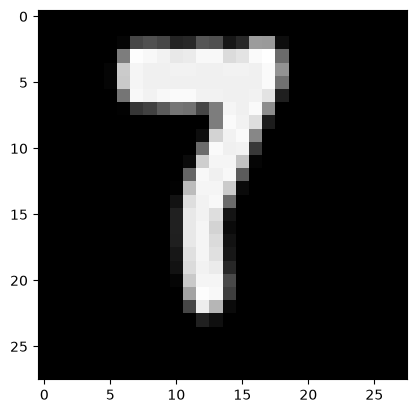

In [141]:
# make prediction

prediction_img = model.predict(img_array)
                                  
prediction_label = np.argmax(prediction_img, axis = 1)
confidence = prediction_img[0][prediction_label]


plt.imshow(img, cmap= 'gray')
plt.title(f"Prediction: {prediction_label} | Confidence: {float(confidence)*100:.2f}% ")
plt.show()

In [140]:
print(y_test[445])

6


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


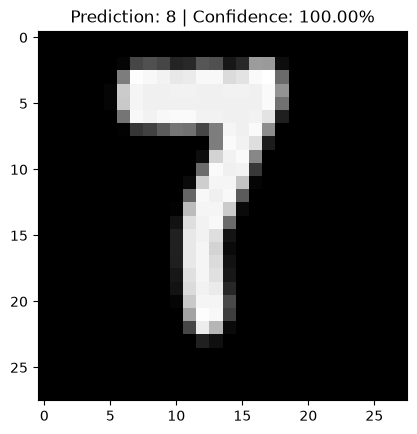

In [122]:
# make prediction

prediction_img = model.predict(img_array)

# Get predicted digit
prediction_label = np.argmax(prediction_img, axis=1)[0]

# Get confidence score
confidence = prediction_img[0][prediction_label]

plt.imshow(img, cmap='gray')
plt.title(f"Prediction: {prediction_label} | Confidence: {confidence*100:.2f}%")
plt.show()



In [142]:
# all of this in one function

import tensorflow as tf
import numpy as np
from PIL import Image, ImageOps

# 1. Load your saved model
model = tf.keras.models.load_model('nomie_digit_recog_model.keras')

def predict_custom_image(path):
    # 2. Open image with PIL
    img = Image.open(path)
    
    # 3. Preprocess: Convert to Grayscale ('L' mode)
    img = img.convert('L')
    
    # 4. Resize to 28x28
    img = img.resize((28, 28))
    
    # 5. Invert Colors (Optional)
    # MNIST data is white ink on black background. 
    # If you drew black ink on white paper, you MUST invert it.
    img = ImageOps.invert(img)
    
    # 6. Convert to Numpy Array and Normalize
    img_array = np.array(img)
    # img_array = img_array/ 255.0 # we did not train our model
    
    # 7. Reshape to match (Batch, Width, Height, Channel)
    # Shape becomes (1, 28, 28, 1)
    img_array = img_array.reshape(1, 28, 28, 1)
    
    # 8. Inference
    prediction = model.predict(img_array)

    result = np.argmax(prediction, axis = 1)
    
    confidence = np.max(prediction)
    
    print(f"Prediction: {result} (Confidence: {confidence*100:.2f}%)")

    return result

In [143]:
# Run it!

path = 'test_1.jpg'

predict_custom_image(path = path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Prediction: [8] (Confidence: 100.00%)


array([8])